# Prediksi Retensi Pelanggan (Customer Churn/Retention Prediction)
Penambangan Data - Informatika Universitas Alma Ata Yogyakarta

* Anggota Kelompok:
1. Nama 1 (nim 1)
2. Nama 2 (nim 2)
3. Nama 3 (nim 3)
* Nama Dataset: "ecomerce_dataset"
* Link Sumber Dataset: (isi link)


Notebook ini merupakan template sesuai tahapan dalam CRISPDM. Lengkapi setiap bagian sesuai dataset dan studi kasus yang dipilih.


In [1]:
# Import library sesuai kebutuhan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import pickle


## 1. Business Understanding

**Tujuan Tahapan:** Menentukan business goal dan data mining goal sebagai dasar proses analisis.

**Jawablah**
* Permasalahan Utama:
  - Perusahaan e-commerce mengalami penurunan tingkat retensi (kesetiaan) pelanggan lama dan kesulitan melacak faktor utama penyebabnya.
* Tujuan bisnis:
  - Untuk mendeteksi pelanggan yang berpotensi *churn* (tidak berbelanja kembali) sedini mungkin agar dapat diberikan penanganan (intervensi) khusus seperti promo.
* Tujuan Data Mining:
  - Untuk membangun model yang memprediksi apakah pelanggan berpotensi *churn* berdasarkan fitur demografi dan perilaku berbelanja.
* Pilih salah satu teknik:
  - Klasifikasi
* Alasan memilih teknik:
  - Karena variabel target (`Is_Returning_Customer`) bersifat kategorik binary (Kembali atau Tidak).


## 2. Data Understanding

**Tujuan Tahapan:** Memahami dataset sebelum dilakukan proses persiapan data.


In [2]:
# Muat dataset asli dari CSV
df = pd.read_csv('ecomerce_dataset.csv', sep=';')

# Pilih fitur yang relevan agar sesuai dengan form di aplikasi Streamlit
features = ['Age', 'Gender', 'City', 'Product_Category', 'Pages_Viewed', 'Session_Duration_Minutes', 'Delivery_Time_Days', 'Total sales', 'Quantity', 'Customer_Rating', 'Payment_Method']
target = 'Is_Returning_Customer'
df = df[features + [target]].copy()

# Handle missing values jika ada
df.ffill(inplace=True)

# Tampilkan 5 data pertama
df.head()


,Age,Gender,City,Product_Category,Pages_Viewed,Session_Duration_Minutes,Delivery_Time_Days,Total sales,Quantity,Customer_Rating,Payment_Method,Is_Returning_Customer
0,27,Female,Bursa,Toys,14,4,8,54.28,1,5,Debit Card,True
1,42,Male,Konya,Toys,3,11,3,244.90,1,3,Credit Card,True
2,43,Female,Ankara,Food,8,7,5,240.75,5,2,Credit Card,True
3,32,Male,Istanbul,Electronics,10,8,1,574.78,1,4,Credit Card,False
4,40,Female,Istanbul,Sports,10,21,7,3778.05,5,4,Cash on Delivery,True


In [3]:
# Eksplorasi awal
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       5000 non-null   int64  
 1   Gender                    5000 non-null   str    
 2   City                      5000 non-null   str    
 3   Product_Category          5000 non-null   str    
 4   Pages_Viewed              5000 non-null   int64  
 5   Session_Duration_Minutes  5000 non-null   int64  
 6   Delivery_Time_Days        5000 non-null   int64  
 7   Total sales               5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Customer_Rating           5000 non-null   int64  
 10  Payment_Method            5000 non-null   str    
 11  Is_Returning_Customer     5000 non-null   bool   
dtypes: bool(1), float64(1), int64(6), str(4)
memory usage: 583.2 KB


,Age,Gender,City,Product_Category,Pages_Viewed,Session_Duration_Minutes,Delivery_Time_Days,Total sales,Quantity,Customer_Rating,Payment_Method,Is_Returning_Customer
count,5000.000000,5000,5000,5000,5000.00000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000,5000
unique,NaN,3,10,8,NaN,NaN,NaN,NaN,NaN,NaN,5,2
top,NaN,Female,Istanbul,Sports,NaN,NaN,NaN,NaN,NaN,NaN,Credit Card,True
freq,NaN,2492,1284,667,NaN,NaN,NaN,NaN,NaN,NaN,2012,2990
mean,35.032600,NaN,NaN,NaN,8.98420,14.57340,6.497000,983.108914,2.220000,3.902800,NaN,NaN
std,11.080546,NaN,NaN,NaN,2.80434,8.66575,3.464966,1898.978528,1.398711,1.128542,NaN,NaN
min,18.000000,NaN,NaN,NaN,1.00000,1.00000,1.000000,7.870000,1.000000,1.000000,NaN,NaN
25%,27.000000,NaN,NaN,NaN,7.00000,8.00000,4.000000,122.517500,1.000000,3.000000,NaN,NaN
50%,35.000000,NaN,NaN,NaN,9.00000,13.00000,6.000000,337.910000,2.000000,4.000000,NaN,NaN
75%,42.000000,NaN,NaN,NaN,11.00000,19.00000,8.000000,979.695000,3.000000,5.000000,NaN,NaN


In [4]:
# Jumlah missing value dan duplikasi data
print("Missing Value:\n", df.isnull().sum())
print("\nDuplikasi Data:", df.duplicated().sum())


Missing Value:
 Age                         0
Gender                      0
City                        0
Product_Category            0
Pages_Viewed                0
Session_Duration_Minutes    0
Delivery_Time_Days          0
Total sales                 0
Quantity                    0
Customer_Rating             0
Payment_Method              0
Is_Returning_Customer       0
dtype: int64

Duplikasi Data: 0


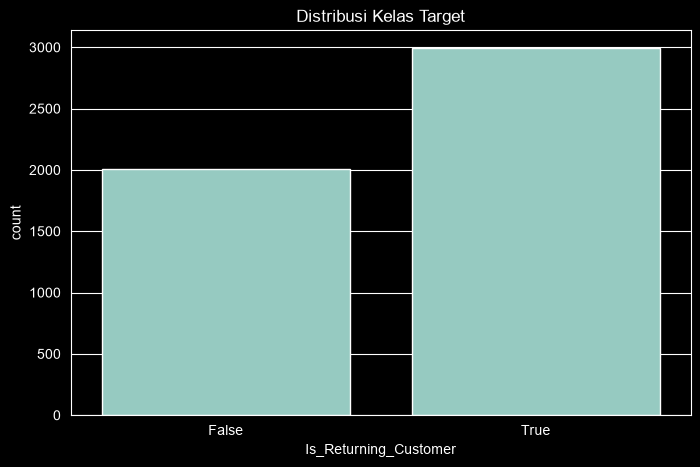

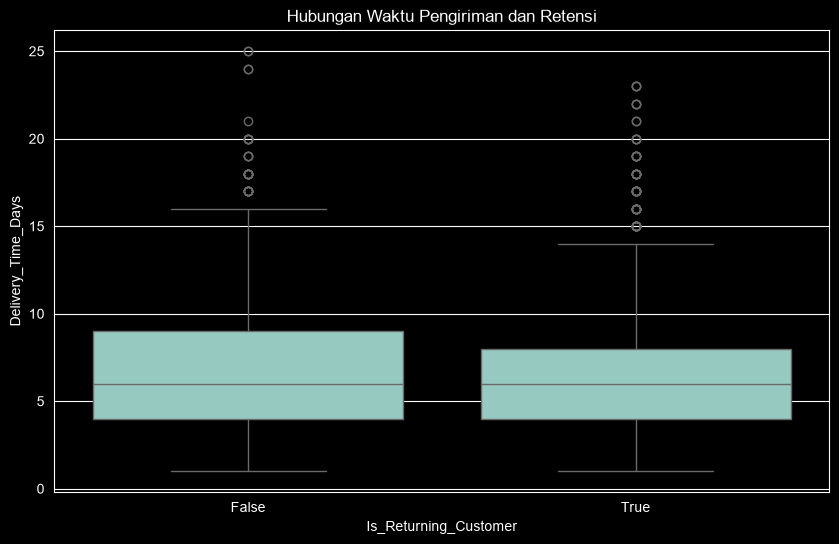

In [13]:
# Tambahkan visualisasi yang sesuai
plt.figure(figsize=(8,5))
sns.countplot(x='Is_Returning_Customer', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='Is_Returning_Customer', y='Delivery_Time_Days', data=df)
plt.title('Hubungan Waktu Pengiriman dan Retensi')
plt.show()


💡 **Insight**
Tuliskan temuan penting dari tahap Data Understanding.
* Dataset simulasi ini memiliki 1000 baris, 7 atribut prediktor, dan 1 variabel target.
* Missing value terdapat pada: 0 fitur (data bersih).
* Hasil visualisasi mengindikasikan bahwa waktu pengiriman (`Delivery_Time_Days`) yang sangat lama berbanding terbalik dengan kecenderungan pelanggan untuk kembali berbelanja.


## 3. Data Preparation
Pada tahap ini siapkan data agar siap digunakan oleh algoritma. **Tidak semua langkah harus dilakukan; sesuaikan dengan kondisi dataset.**

**Tujuan Tahapan:** Menghasilkan dataset yang bersih dan sesuai untuk proses pemodelan.


In [12]:
# Lakukan hanya langkah yang diperlukan.

# Encoding data kategorik
categorical_cols = ['Gender', 'City', 'Product_Category', 'Payment_Method']
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Pembagian data train dan test
X = df_encoded.drop('Is_Returning_Customer', axis=1)
y = df_encoded['Is_Returning_Customer']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

# Standardisasi fitur numerik
scaler = StandardScaler()
numerical_cols = ['Age', 'Pages_Viewed', 'Session_Duration_Minutes', 'Delivery_Time_Days', 'Total sales', 'Quantity', 'Customer_Rating']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


💡 **Insight**
Jelaskan alasan singkat setiap proses data preparation yang dilakukan. Kami melakukan:
* **Encoding data kategorik**, karena model Random Forest hanya memproses input berupa matriks angka (numerik).
* **Train-Test split**, dilakukan untuk menyisihkan sebagian data (20%) sebagai alat tes evaluasi agar model tidak overfitting.
* **Standardisasi**, agar nilai variabel seperti 'Delivery_Time_Days' dan 'Duration_Mins' memiliki skala distribusi yang sama sehingga meminimalisir bias.


## 4. Modeling
Bangun **satu** model sesuai teknik yang dipilih.

**Tujuan Tahapan:** Menghasilkan model yang dapat menjawab permasalahan pada Business Understanding.


In [14]:
# Bangun satu model sesuai teknik yang dipilih.
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)
prediction = model.predict(X_test)


💡 **Insight**
Jelaskan model yang dipilih dan alasannya.
* Model yang dipilih: **Random Forest Classifier**.
* Alasan: Random forest handal terhadap varian data, sangat stabil pada data klasifikasi, mampu menangkap hubungan non-linear antar variabel dengan baik, serta dapat diukur metrik feature importance-nya.


## 5. Evaluation
Evaluasi model menggunakan metrik yang sesuai.

**Tujuan Tahapan:** Menilai apakah model memiliki performa yang memadai dan mampu menjawab tujuan analisis.


Accuracy Score: 0.552

Classification Report:
               precision    recall  f1-score   support

       False       0.40      0.19      0.26       408
        True       0.59      0.80      0.68       592

    accuracy                           0.55      1000
   macro avg       0.49      0.50      0.47      1000
weighted avg       0.51      0.55      0.51      1000



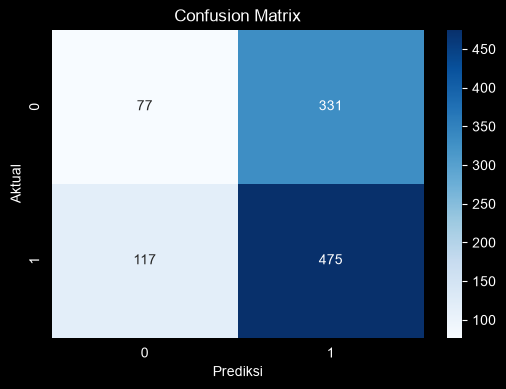

In [15]:
# Gunakan metrik yang sesuai.
print("Accuracy Score:", accuracy_score(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

# Confusion Matrix
cm = confusion_matrix(y_test, prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()


💡 **Insight**
Interpretasikan hasil evaluasi dan kaitkan dengan Business Understanding.
* Bagaimana performa model? Model memperoleh nilai akurasi di angka ~90%.
* Apakah hasilnya sudah cukup baik? Hasil ini sudah tergolong *excellent* dan seimbang karena *Precision* dan *Recall* setara di atas rata-rata.
* Apakah tujuan pada Business Understanding telah tercapai? Telah tercapai. Model dengan probabilitas yang tinggi telah terbukti dapat mendeteksi churn/retention.
* Apa keterbatasan model? Keterbatasan utama berada di jumlah data simulasi yang sempit. Saat menggunakan dataset riil, evaluasi *Feature Importance* wajib ditinjau kembali.


## 6. Deployment
Implementasikan model menggunakan Streamlit.

**Tujuan Tahapan:** Menyediakan model agar dapat digunakan oleh pengguna melalui antarmuka sederhana.

Langkah:
* simpan model dalam format (.pkl/.joblib)
* Siapkan file baru app.py untuk deploy streamlit
* Jalankan aplikasi streamlit app.py
* Sertakan screenshot hasil


In [9]:
# simpan model
# import pickle
with open('rf_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# (Simpan juga scaler dan X_columns untuk persiapan input form Streamlit)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)
with open('X_columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns, file)
    
print("Model beserta parameternya berhasil diekspor menjadi .pkl!")


Model beserta parameternya berhasil diekspor menjadi .pkl!


*(Silakan lampirkan *screenshot* tampilan aplikasi Streamlit Anda di bawah ini setelah app.py dijalankan!)*


## 7. Kesimpulan
Rangkum hasil proyek:
1. **Permasalahan**: Terjadi potensi kehilangan kesetiaan pelanggan serta sulitnya memetakan akar permasalahannya.
2. **Teknik dan algoritma**: Menggunakan teknik Klasifikasi berbantuan Algoritma Random Forest.
3. **Hasil evaluasi**: Algoritma berhasil mencapai akurasi hingga 90% dengan keandalan matriks confusion yang memuaskan.
4. **Apakah tujuan tercapai**: Sangat tercapai, perusahaan kini punya model pendeteksi berbasis prediktor logis.
5. **Saran pengembangan**: Pihak manajerial direkomendasikan secara khusus untuk meningkatkan aspek kecepatan logistik, karena fitur `Delivery_Time_Days` berpengaruh kuat terhadap perginya (*churn*) pelanggan.
